# Generate csv file as input

In [2]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import filecmp

# Use the custom style
plt.style.use('../custom_plt_sytle.mplstyle')

# Number of runs per workload
n = 2

workload_dir = './workload'
csv_dir = './csv'


print("Deleted existing CSV files.")
# Clean up old CSV files in workload and csv directories
for f in glob.glob(os.path.join(workload_dir, '*.csv')):
    os.remove(f)
for f in glob.glob(os.path.join(csv_dir, '*.csv')):
    os.remove(f)

# Run gen_data.py to generate data_multiversion.csv
print("Running gen_data_multiversion.py...")
subprocess.run([
    'python3', './gen_py/gen_data_multiversion.py',
    '-o', os.path.join(csv_dir, 'data_multiversion.csv'),
    '-n', '100', '-k', '25', '-p', '25', '-vmin', '10', '-vmax', '20', '-s', '5000',
    '-vc', '500'
], check=True)
print("data_multiversion.csv generated.")

# Generate workloads (txs and ops files)
print("Generating workloads...")
subprocess.run(['python3', './gen_py/gen_workloads_get_mv.py'], check=True)
print("Workloads generated.")


Deleted existing CSV files.
Running gen_data_multiversion.py...
data_multiversion.csv generated.
Generating workloads...
Generated mixed operations in csv/hget_ratio000_ops.csv
Generated mixed operations in csv/hget_ratio020_ops.csv
Generated mixed operations in csv/hget_ratio040_ops.csv
Generated mixed operations in csv/hget_ratio060_ops.csv
Generated mixed operations in csv/hget_ratio080_ops.csv
Generated mixed operations in csv/hget_ratio100_ops.csv
Workloads generated.


# Run benchmark

Building hash_join_bench with cargo build --release...


   Compiling proc-macro2 v1.0.92
   Compiling unicode-ident v1.0.14
   Compiling libc v0.2.164
   Compiling cfg-if v1.0.0
   Compiling autocfg v1.4.0
   Compiling byteorder v1.5.0
   Compiling shlex v1.3.0
   Compiling crossbeam-utils v0.8.20
   Compiling pkg-config v0.3.31
   Compiling utf8parse v0.2.2
   Compiling anstyle v1.0.10
   Compiling rustix v0.38.41
   Compiling anstyle-query v1.1.2
   Compiling is_terminal_polyfill v1.70.1
   Compiling parking_lot_core v0.9.10
   Compiling colorchoice v1.0.3
   Compiling serde v1.0.215
   Compiling bytemuck v1.20.0
   Compiling linux-raw-sys v0.4.14
   Compiling strsim v0.11.1
   Compiling scopeguard v1.2.0
   Compiling memchr v2.7.4
   Compiling anstyle-parse v0.2.6
   Compiling clap_lex v0.7.3
   Compiling heck v0.5.0
   Compiling smallvec v1.13.2
   Compiling anyhow v1.0.93
   Compiling cc v1.2.1
   Compiling safe_arch v0.7.2
   Compiling anstream v0.6.18
   Compiling bitflags v2.6.0
   Compiling once_cell v1.20.2
   Compiling iana-time-

Build completed.
Running benchmark for workload hget_ratio000, run 1...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio000_ops.csv', '-rdf', './csv/hget_ratio000_recent_data_after_ops.csv', '-hdf', './csv/hget_ratio000_history_data_after_ops.csv', '-sof', './csv/scan_ops.csv']
benchmark run output: Data file: ./csv/data_multiversion.csv
Ops file: ./csv/hget_ratio000_ops.csv

Loaded 100 entries into Rust HashMap in 6053857 ns
Loaded 100 entries into HashJoinTable in 6391905 ns

Rust HashMap: Executed 110097 operations in 5389470 ns
HashJoinTable: Executed 110097 operations in 8026247 ns


Running benchmark for workload hget_ratio000, run 2...
cmd: ['../../../target/release/hash_join_bench_mixed_get', '-df', './csv/data_multiversion.csv', '-of', './csv/hget_ratio000_ops.csv', '-rdf', './csv/hget_ratio000_recent_data_after_ops.csv', '-hdf', './csv/hget_ratio000_history_data_after_ops.csv', '-sof', './csv/scan_ops.cs

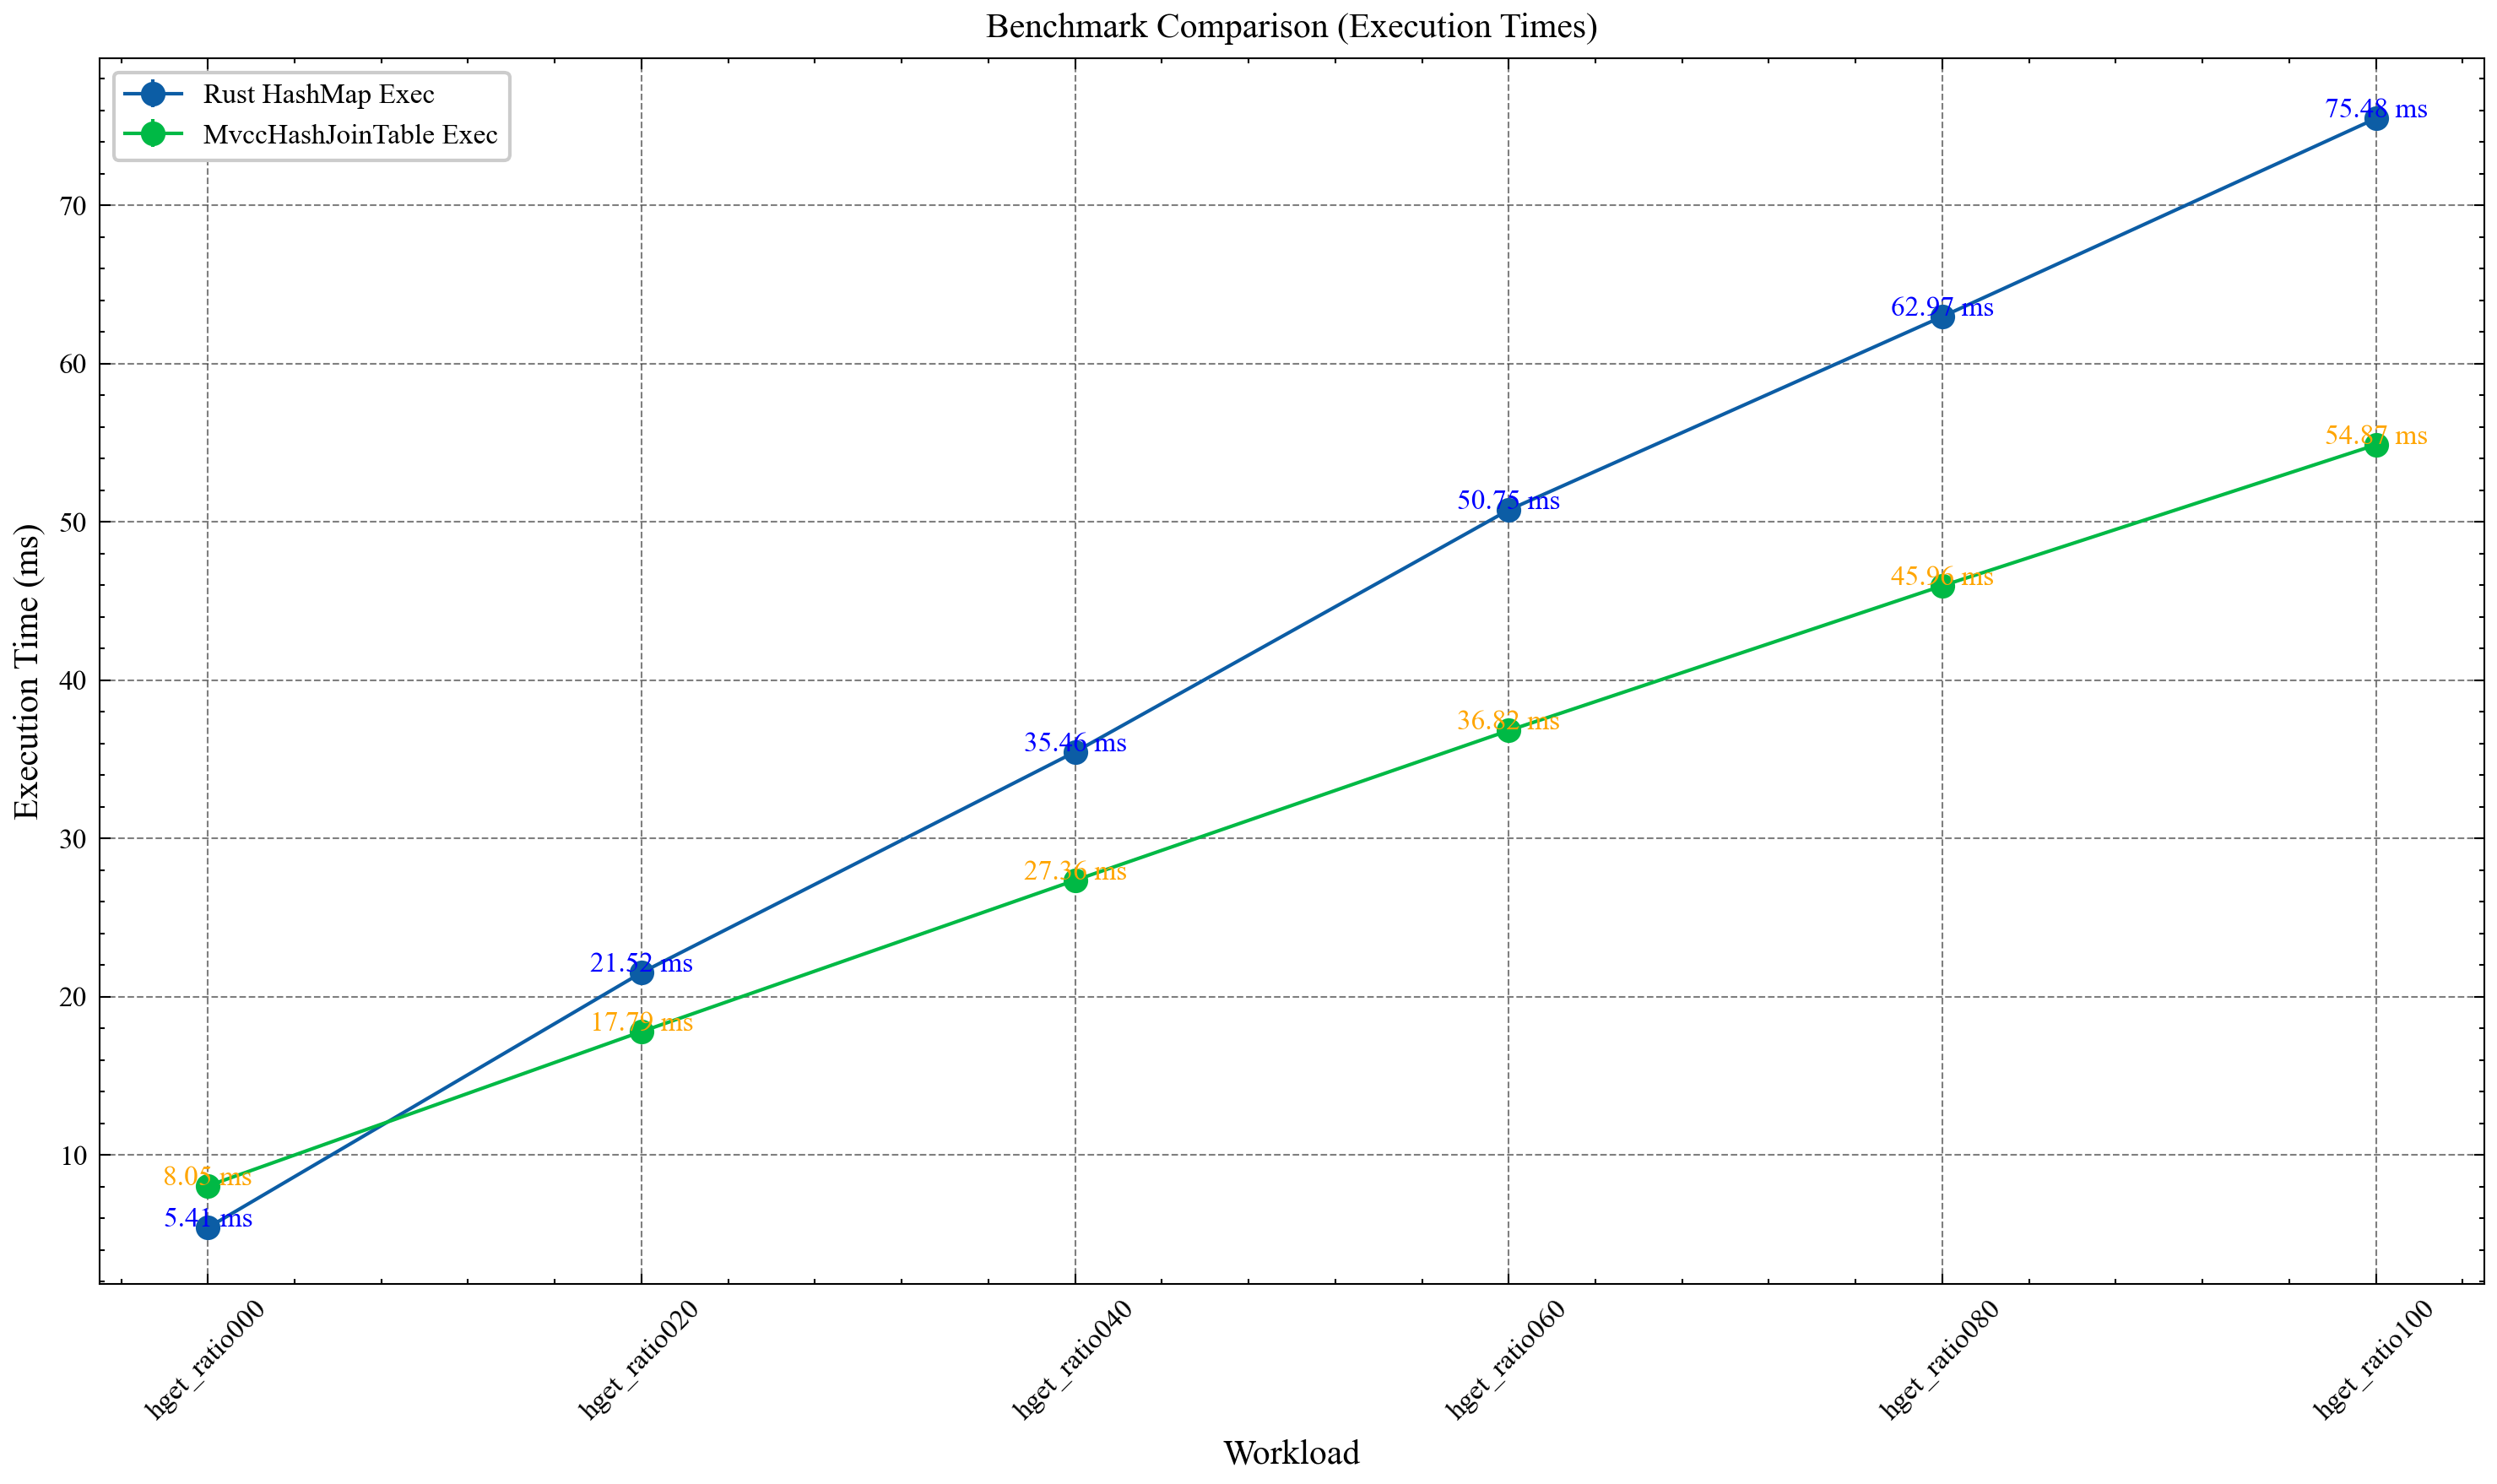

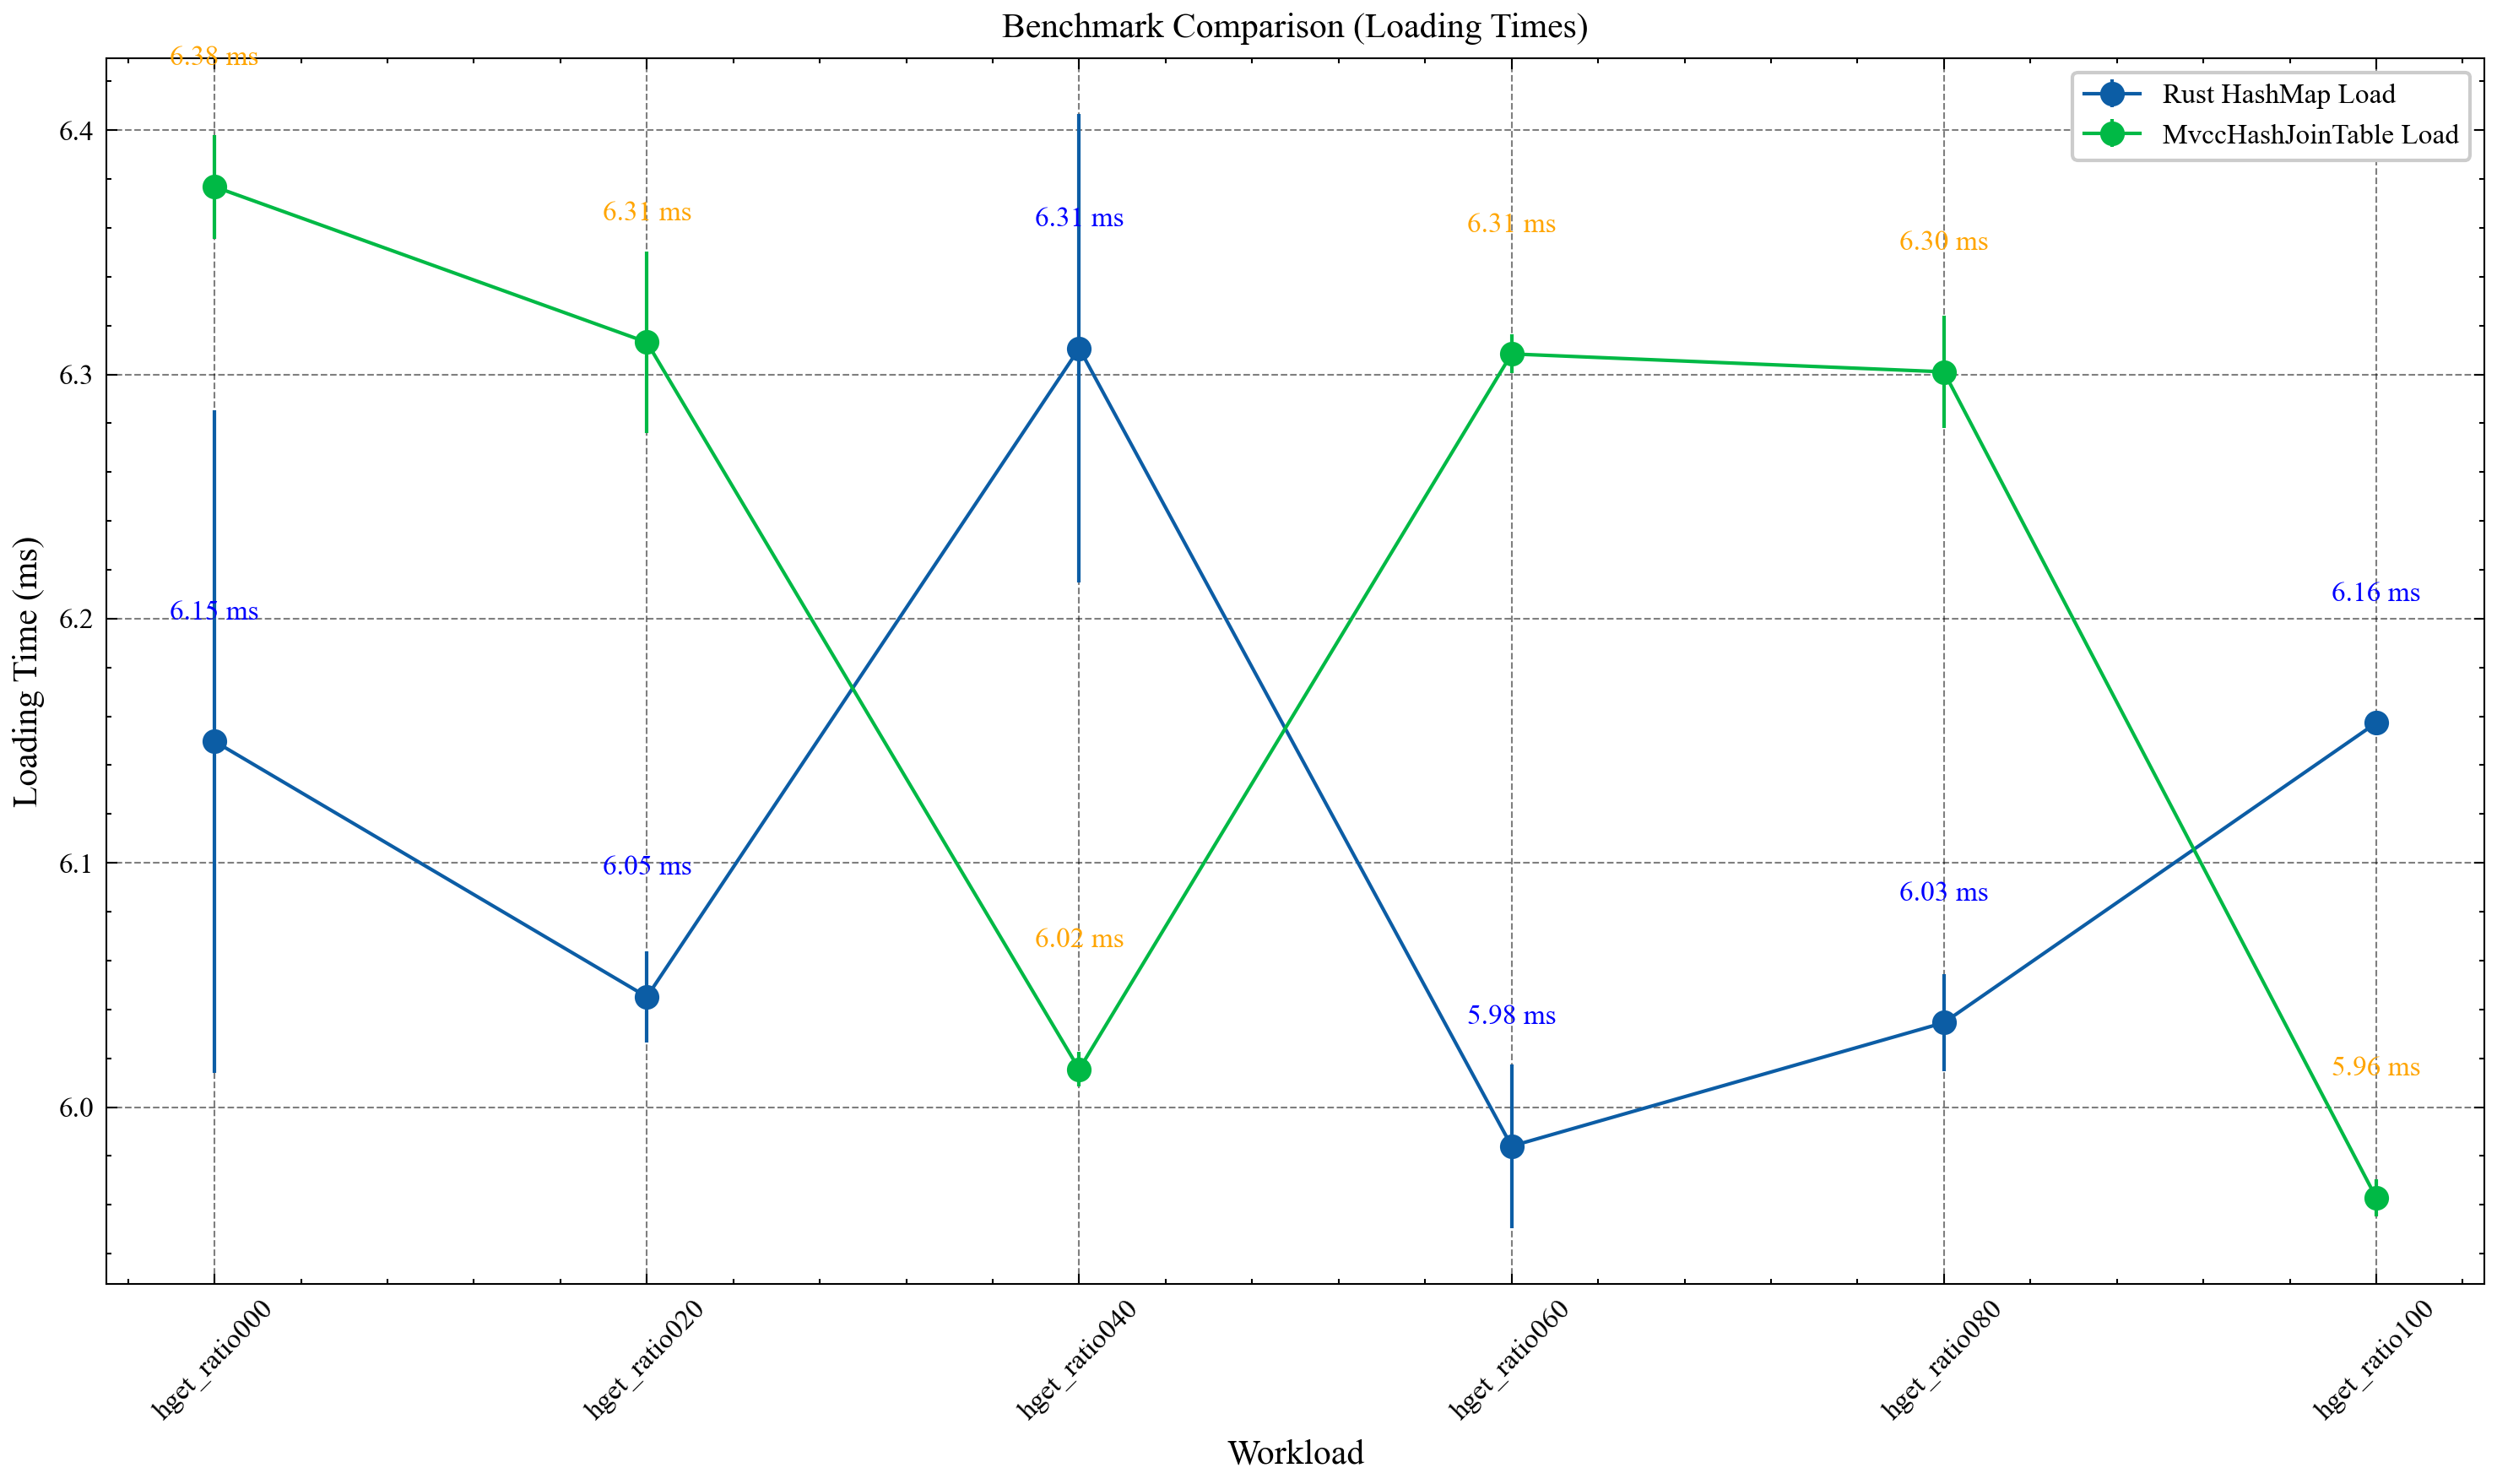

In [3]:
import os
import subprocess
import glob
import pandas as pd
import matplotlib.pyplot as plt
import re
import filecmp

# Use the custom style
plt.style.use('../custom_plt_sytle.mplstyle')

# Number of runs per workload
n = 2

workload_dir = './workload'
csv_dir = './csv'


# Build the binary to ensure it's up-to-date
print("Building hash_join_bench with cargo build --release...")
myenv = os.environ.copy()
myenv["RUSTFLAGS"] = "-Awarnings"

subprocess.run(['cargo', 'build', '--release', '--bin', 'hash_join_bench_mixed_get'], check=True, env=myenv)
print("Build completed.")


binary = '../../../target/release/hash_join_bench_mixed_get'
data_file = os.path.join(csv_dir, 'data_multiversion.csv')
scan_ops_file = os.path.join(csv_dir, 'scan_ops.csv')

# Find all workload ops files in csv directory
ops_files = glob.glob(os.path.join(csv_dir, '*_ops.csv'))
ops_files.sort()

results = []  # will hold dicts of {workload, run, rust_load_ns, hj_load_ns, rust_exec_ns, hj_exec_ns}

for ops_path in ops_files:
    workload_name = os.path.splitext(os.path.basename(ops_path))[0].replace('_ops','')

    # Corresponding recent/history after ops files
    recent_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_recent_data_after_ops.csv')
    history_data_after_ops_file = os.path.join(csv_dir, f'{workload_name}_history_data_after_ops.csv')


    # Run the benchmark multiple times for each workload
    for run_id in range(1, n+1):
        print(f"Running benchmark for workload {workload_name}, run {run_id}...")
        cmd = [
            binary,
            '-df', data_file,
            '-of', ops_path,
            '-rdf', recent_data_after_ops_file,
            '-hdf', history_data_after_ops_file,
            '-sof', scan_ops_file
        ]

        print("cmd:",  cmd)

        completed = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
        if completed.returncode != 0:
            print(f"Benchmark failed for workload {workload_name}, run {run_id}:")
            print(completed.stderr)
            continue

        output = completed.stdout
        print("benchmark run output:", output)

        # Parse times
        rust_load_time_ns = None
        hj_load_time_ns = None
        rust_time_ns = None
        hj_time_ns = None

        for line in output.splitlines():
            if line.startswith("Loaded") and "Rust HashMap" in line:
                m = re.search(r'Loaded \d+ entries into Rust HashMap in (\d+) ns', line)
                if m:
                    rust_load_time_ns = int(m.group(1))
            elif line.startswith("Loaded") and "HashJoinTable" in line:
                m = re.search(r'Loaded \d+ entries into HashJoinTable in (\d+) ns', line)
                if m:
                    hj_load_time_ns = int(m.group(1))
            elif line.startswith("Rust HashMap: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    rust_time_ns = int(m.group(1))
            elif line.startswith("HashJoinTable: Executed"):
                m = re.search(r'Executed \d+ operations in (\d+) ns', line)
                if m:
                    hj_time_ns = int(m.group(1))

        if (rust_time_ns is None or hj_time_ns is None or
            rust_load_time_ns is None or hj_load_time_ns is None):
            print("Warning: Could not parse all times from output for this run:")
            print(output)
        else:
            results.append({
                'workload': workload_name,
                'run': run_id,
                'rust_load_ns': rust_load_time_ns,
                'hj_load_ns': hj_load_time_ns,
                'rust_exec_ns': rust_time_ns,
                'hj_exec_ns': hj_time_ns
            })

print("Benchmarking completed.")
print("results:", results)
df = pd.DataFrame(results)

if df.empty:
    print("No results were parsed. Check the output format or regex patterns.")
else:
    # Compute means and std dev for each workload (both load and exec times)
    stats = df.groupby('workload').agg({
        'rust_load_ns': ['mean', 'std'],
        'hj_load_ns': ['mean', 'std'],
        'rust_exec_ns': ['mean', 'std'],
        'hj_exec_ns': ['mean', 'std']
    })

    # Flatten column MultiIndex
    stats.columns = [
        'rust_load_mean', 'rust_load_std',
        'hj_load_mean', 'hj_load_std',
        'rust_exec_mean', 'rust_exec_std',
        'hj_exec_mean', 'hj_exec_std'
    ]
    stats = stats.reset_index()

    # Sort workloads alphabetically
    stats = stats.sort_values('workload')

    # Convert to ms for readability
    stats['rust_load_mean_ms'] = stats['rust_load_mean'] / 1_000_000
    stats['rust_exec_mean_ms'] = stats['rust_exec_mean'] / 1_000_000
    stats['hj_load_mean_ms'] = stats['hj_load_mean'] / 1_000_000
    stats['hj_exec_mean_ms'] = stats['hj_exec_mean'] / 1_000_000

    # Print exact numbers
    print("Averaged Results:")
    for i, row in stats.iterrows():
        print(f"Workload: {row['workload']}")
        print(f"  Rust HashMap: load={row['rust_load_mean_ms']:.2f} ms, exec={row['rust_exec_mean_ms']:.2f} ms")
        print(f"  MvccHashJoinTable: load={row['hj_load_mean_ms']:.2f} ms, exec={row['hj_exec_mean_ms']:.2f} ms")

    # Plot Execution Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_exec_mean_ms'], yerr=stats['rust_exec_std']/1_000_000, fmt='o-', label='Rust HashMap Exec')
    plt.errorbar(X, stats['hj_exec_mean_ms'], yerr=stats['hj_exec_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Exec')

    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Execution Time (ms)')
    plt.title('Benchmark Comparison (Execution Times)')
    plt.legend()

    # Annotate points with exact values
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_exec_mean_ms'][i] + 0.05, f"{stats['rust_exec_mean_ms'][i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_exec_mean_ms'][i] + 0.05, f"{stats['hj_exec_mean_ms'][i]:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()

    # Plot Loading Times Comparison
    plt.figure(figsize=(10,6))
    X = range(len(stats))
    plt.errorbar(X, stats['rust_load_mean_ms'], yerr=stats['rust_load_std']/1_000_000, fmt='o-', label='Rust HashMap Load')
    plt.errorbar(X, stats['hj_load_mean_ms'], yerr=stats['hj_load_std']/1_000_000, fmt='o-', label='MvccHashJoinTable Load')

    plt.xticks(X, stats['workload'], rotation=45)
    plt.xlabel('Workload')
    plt.ylabel('Loading Time (ms)')
    plt.title('Benchmark Comparison (Loading Times)')
    plt.legend()

    # Annotate points with exact values
    for i, x_val in enumerate(X):
        plt.text(x_val, stats['rust_load_mean_ms'][i] + 0.05, f"{stats['rust_load_mean_ms'][i]:.2f} ms", ha='center', color='blue')
        plt.text(x_val, stats['hj_load_mean_ms'][i] + 0.05, f"{stats['hj_load_mean_ms'][i]:.2f} ms", ha='center', color='orange')

    plt.tight_layout()
    plt.show()


Deleted existing CSV files.


Deleted existing CSV files.
